In [ ]:
import pandas as pd 
import numpy as np 
from x01_get_irs import get_irs_data
import matplotlib.pyplot as plt

# KORIBOR
# http://www.smbs.biz/Eng/Funds/Koribor.jsp
df_koribor = pd.DataFrame(
    columns = [
        "tenor", "1W", "1M", "2M", "3M", "6M", "12M"],
    data = [
        ["20241231", 3.00, 3.12, 3.24, 3.36, 3.33, 3.05],
        ["20250331", 2.75, 2.78, 2.81, 2.85, 2.84, 2.83],
        ["20250630", 2.50, 2.52, 2.53, 2.55, 2.54, 2.56],
        ["20250930", 2.50, 2.51, 2.52, 2.54, 2.58, 2.59],
        ["20251231", 2.50, 2.62, 2.71, 2.82, 2.84, 2.82],
]).set_index("tenor", drop=True)

# Quoted IRS rates
# http://www.smbs.biz/Eng/Exchange/IRS.jsp
dfs = {
    dt.replace(".","") : get_irs_data(dt) for dt in ["2024.12.31","2025.03.31","2025.06.30","2025.09.30","2025.12.31"]
}
df_irs = pd.concat(dfs)

df_irs

1Y    2Y    3Y    4Y    5Y    7Y   10Y   12Y   15Y   20Y
         Tenure                                                             
20241231 Receive  2.87  2.74  2.72  2.72  2.73  2.75  2.78  2.80  2.74  2.58
         Mid      2.86  2.73  2.71  2.72  2.72  2.74  2.77  2.79  2.73  2.58
         Pay      2.85  2.72  2.70  2.70  2.71  2.73  2.76  2.78  2.72  2.56
20250331 Receive  2.67  2.58  2.56  2.57  2.58  2.61  2.64  2.66  2.62  2.51
         Mid      2.66  2.57  2.55  2.56  2.57  2.60  2.63  2.65  2.61  2.50
         Pay      2.65  2.56  2.54  2.55  2.56  2.59  2.62  2.64  2.60  2.49
20250630 Receive  2.45  2.40  2.42  2.46  2.49  2.56  2.63  2.66  2.64  2.53
         Mid      2.44  2.39  2.41  2.45  2.48  2.55  2.62  2.65  2.63  2.52
         Pay      2.43  2.38  2.40  2.44  2.47  2.54  2.61  2.64  2.62  2.51
20250930 Receive  2.50  2.50  2.54  2.60  2.65  2.71  2.78  2.82  2.81  2.73
         Mid      2.49  2.49  2.53  2.59  2.64  2.70  2.78  2.81  2.80  2.72
         Pay      2.48  2.48  2.52  2.58  2.63  2.69  2.76  2.80  2.79  2.71
20251231 Receive  2.79  2.93  3.04  3.10  3.16  3.22  3.27  3.30  3.29  3.19
         Mid      2.78  2.92  3.03  3.10  3.15  3.21  3.26  3.30  3.28  3.18
         Pay      2.77  2.91  3.02  3.08  3.14  3.20  3.25  3.28  3.27  3.17

,1W,1M,2M,3M,6M,12M,1Y,2Y,3Y,4Y,5Y,7Y,10Y,12Y,15Y,20Y
20241231,3.00,3.12,3.24,3.36,3.33,3.05,2.86,2.73,2.71,2.72,2.72,2.74,2.77,2.79,2.73,2.58
20250331,2.75,2.78,2.81,2.85,2.84,2.83,2.66,2.57,2.55,2.56,2.57,2.60,2.63,2.65,2.61,2.50
20250630,2.50,2.52,2.53,2.55,2.54,2.56,2.44,2.39,2.41,2.45,2.48,2.55,2.62,2.65,2.63,2.52
20250930,2.50,2.51,2.52,2.54,2.58,2.59,2.49,2.49,2.53,2.59,2.64,2.70,2.78,2.81,2.80,2.72
20251231,2.50,2.62,2.71,2.82,2.84,2.82,2.78,2.92,3.03,3.10,3.15,3.21,3.26,3.30,3.28,3.18


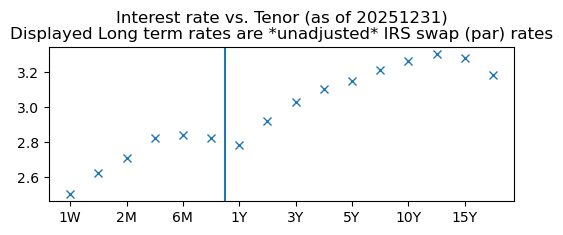

In [60]:
df_irs_mid = df_irs.loc[(slice(None), "Mid"), :].droplevel(1)
df_concat = pd.concat([df_koribor, df_irs_mid], axis=1).astype(float)
df_concat.iloc[-1].plot(figsize=(6,2), marker="x", lw=0, title="Interest rate vs. Tenor (as of 20251231)\nDisplayed Long term rates are *unadjusted* IRS swap (par) rates")
plt.axvline(5.5)

df_concat

## KORIBOR/Swap curve vs. KORIBOR/Swap zero rate curve (spot rates)

IRS contract have multiple cashflow. 

(KORIBOR/Swap : IRS contract with KORIBOR as floating leg and Swap rate as fixed leg)

* *Swap rates* are the *'coupon' rates* for par contract.
* *Zero rates* are the *discount factors* for a single cashflow at maturity (like zero coupon bond)

## Forward rate

F(t; T1, T1 + 3M) : 3M Forward rate(T1-t forward 3M rate) for T1, as of time t (projected from the tenor curve)

## How to derive spot rate from swap market data?

Bootstraping

In [ ]:
# We assume payment frequency 3M
df_spot = df_koribor.iloc[:, -3:].copy()
df_spot.columns = df_spot.columns.map(lambda x: int(x.replace("M","")))
df_spot[9] = 0.5 * (df_spot[6] + df_spot[12]) # assuming linear curve
df_spot.sort_index(axis=1, inplace=True)
print("Spot rates")
print(df_spot)
print()
dcs = np.exp(- df_spot * 0.01 * df_spot.columns / 12)
print("Discount rates")
print(dcs)
print()
print()
df_forward = (df_spot * df_spot.columns / 12).diff(axis=1) / (3/12)
df_forward.iloc[:,0] = df_spot.iloc[:,0]
print("xM Forward 3M rates -> Expected IRS floating leg cashflow")
print(df_forward)
print()
df_PV = (df_forward * dcs).sum(axis=1) + (100 * dcs.iloc[:,-1])
print("PV of floating leg cashflow")
print(df_PV)
print()
# print("YTM of this bond --> spot rate")
# print("zero rate --> spot zero rate")

Spot rates
            3     6      9     12
tenor                            
20241231  3.36  3.33  3.190  3.05
20250331  2.85  2.84  2.835  2.83
20250630  2.55  2.54  2.550  2.56
20250930  2.54  2.58  2.585  2.59
20251231  2.82  2.84  2.830  2.82

Discount rates
                3         6         9         12
tenor                                           
20241231  0.991635  0.983488  0.976359  0.969960
20250331  0.992900  0.985900  0.978962  0.972097
20250630  0.993645  0.987380  0.981057  0.974725
20250930  0.993670  0.987183  0.980799  0.974433
20251231  0.992975  0.985900  0.978999  0.972194


xM Forward 3M rates -> Expected IRS floating leg cashflow
            3     6      9      12
tenor                             
20241231  3.36  3.30  2.910  2.630
20250331  2.85  2.83  2.825  2.815
20250630  2.55  2.53  2.570  2.590
20250930  2.54  2.62  2.595  2.605
20251231  2.82  2.86  2.810  2.790

PV of floating leg cashflow
tenor
20241231    108.965648
20250331    108.331553
202506

## Interest rate swap

Fixing in advance 

### Cashflow schedule of fixed rate payer

* 2024-12
  * Transaction : Agreed to pay X% p.a, receive LIBOR 3mo. Maturity 1y.
  * Settlement : L3 = Fixing rate 3.36%

* 2026-03
  * Settlement : L6 = Fixing rate 2.85%
  * Payment : X/4% - 3.36$

* 2026-06
  * Settlement : L9 = Fixing rate 2.55%
  * Payment : X/4% - 2.85$

* 2026-09
  * Settlement : L9 = Fixing rate 2.54%
  * Payment : X/4% - 2.55$

* 2026-09
  * Payment : X/4% - 2.54$

### Decomposition into floating rate and fixed rate bond



#### Floating leg

#### Fixed leg